# Chapter 19 — Multiple Linear Regression

## Learning Objectives

By the end of this chapter, you will be able to:

- Explain why multiple regression extends simple linear regression
- Write and interpret a multiple linear regression model
- Interpret a coefficient while holding the other predictors constant
- Fit a multiple regression model with `statsmodels`
- Distinguish $R^2$ from adjusted $R^2$
- Test individual regression coefficients
- Interpret the overall F-test
- Examine residual diagnostics
- Understand the basic idea of multicollinearity
- Use Variance Inflation Factor (VIF) as a diagnostic
- Compare a simple and multiple regression model carefully
- Avoid unsupported causal interpretations


## 1. From Simple Regression to Multiple Regression

Chapter 18 used one predictor:

$$
Y = \beta_0 + \beta_1X + \varepsilon
$$

Real outcomes often relate to more than one variable.

Multiple linear regression extends the model by including several predictors:

$$
Y
=
\beta_0
+
\beta_1X_1
+
\beta_2X_2
+
\cdots
+
\beta_pX_p
+
\varepsilon
$$

The mathematical extension is straightforward.

The **interpretation of each coefficient** is the important new idea.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the project root containing a data/ directory.")

ROOT = find_project_root(Path.cwd())
DATA_PATH = ROOT / "data" / "19_multiple_linear_regression.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,employee_id,training_hours,experience_years,project_load,performance_score
0,E001,10.3,11.7,6,86.1
1,E002,4.3,6.9,5,42.2
2,E003,4.1,12.9,7,61.1
3,E004,6.4,10.6,7,66.3
4,E005,4.1,1.9,6,53.1


## 2. Dataset

The dataset contains **120 fictional employees**.

| Variable | Role | Description |
|---|---|---|
| `employee_id` | ID | Fictional employee identifier |
| `training_hours` | Predictor | Training hours |
| `experience_years` | Predictor | Years of work experience |
| `project_load` | Predictor | Number of active projects |
| `performance_score` | Outcome | Performance assessment score |

All data are synthetic and are used only for statistical learning.


In [2]:
df.describe()


,training_hours,experience_years,project_load,performance_score
count,120.000000,120.000000,120.000000,120.000000
mean,5.151667,7.726667,4.116667,63.021667
std,2.739257,3.971553,2.091131,12.204781
min,0.500000,0.600000,1.000000,35.000000
25%,3.275000,4.400000,2.000000,53.100000
50%,4.600000,7.300000,4.000000,62.400000
75%,7.200000,11.075000,6.000000,71.125000
max,11.900000,14.600000,7.000000,95.100000


## 3. Research Question

We want to examine how performance score is associated with:

- training hours
- experience
- project load

simultaneously.

Our model is

$$
Y
=
\beta_0
+
\beta_1X_1
+
\beta_2X_2
+
\beta_3X_3
+
\varepsilon
$$

where:

- $Y$ = performance score
- $X_1$ = training hours
- $X_2$ = experience years
- $X_3$ = project load


## 4. First Inspect the Variables

Multiple regression does not remove the need for exploratory analysis.

Start with descriptive statistics and pairwise relationships.


In [3]:
variables = [
    "training_hours",
    "experience_years",
    "project_load",
    "performance_score",
]

df[variables].corr()


,training_hours,experience_years,project_load,performance_score
training_hours,1.000000,0.400509,-0.146150,0.721707
experience_years,0.400509,1.000000,-0.017478,0.597173
project_load,-0.146150,-0.017478,1.000000,-0.326893
performance_score,0.721707,0.597173,-0.326893,1.000000


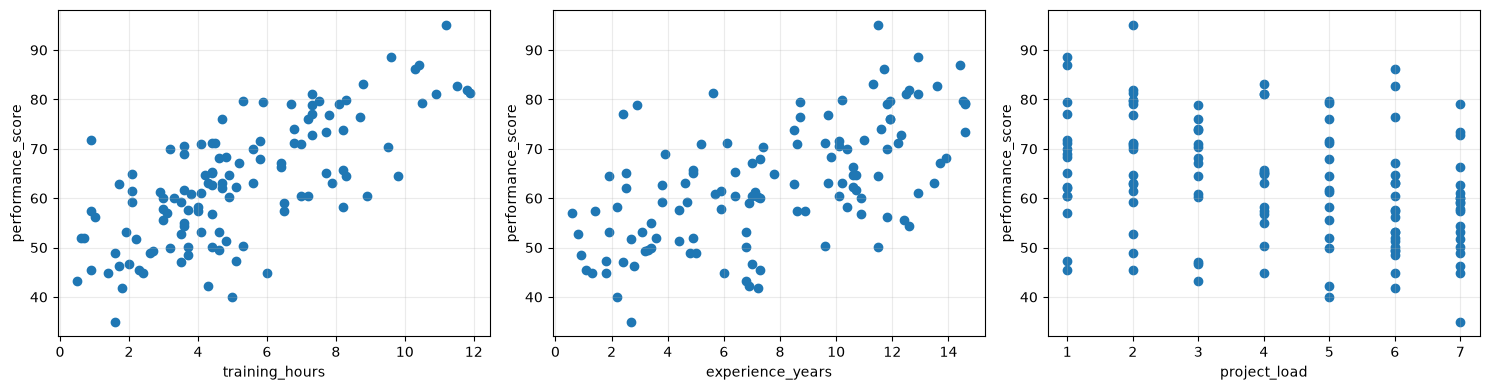

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictors = ["training_hours", "experience_years", "project_load"]

for ax, predictor in zip(axes, predictors):
    ax.scatter(df[predictor], df["performance_score"])
    ax.set_xlabel(predictor)
    ax.set_ylabel("performance_score")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


Pairwise plots are useful, but they do not show what happens when the predictors are considered **together**.

That is the role of multiple regression.


## 5. Fit the Multiple Regression Model

As in Chapter 18, `statsmodels` requires us to add the intercept explicitly.


In [5]:
X = df[["training_hours", "experience_years", "project_load"]]
X = sm.add_constant(X)

y = df["performance_score"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      performance_score   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.683
Method:                 Least Squares   F-statistic:                     86.55
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.82e-29
Time:                        16:12:06   Log-Likelihood:                -399.49
No. Observations:                 120   AIC:                             807.0
Df Residuals:                     116   BIC:                             818.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               47.5737      2.099  

## 6. The Fitted Equation

The fitted model has the form

$$
\hat{Y}
=
b_0
+
b_1X_1
+
b_2X_2
+
b_3X_3
$$


In [6]:
model.params


const               47.573711
training_hours       2.381879
experience_years     1.164170
project_load        -1.413241
dtype: float64

In [7]:
print(
    f"Performance Score = {model.params['const']:.2f}"
    f" + {model.params['training_hours']:.2f} × Training Hours"
    f" + {model.params['experience_years']:.2f} × Experience Years"
    f" + {model.params['project_load']:.2f} × Project Load"
)


Performance Score = 47.57 + 2.38 × Training Hours + 1.16 × Experience Years + -1.41 × Project Load


## 7. The Most Important Idea: Holding Other Predictors Constant

In simple regression, a slope describes the estimated change in $Y$ associated with a one-unit change in $X$.

In multiple regression, each slope has an additional condition:

> Interpret one predictor **while holding the other predictors constant**.

For example, $b_1$ for training hours describes the estimated difference in performance score associated with one additional training hour **for employees with the same values of experience and project load**.

This is often called an **adjusted** or **partial** association.

It is not automatically a causal effect.


### Interpreting Each Coefficient

If the fitted coefficients are approximately:

- training hours: positive
- experience years: positive
- project load: negative

then the interpretations are:

- More training hours are associated with a higher fitted performance score, holding experience and project load constant.
- More experience is associated with a higher fitted performance score, holding training hours and project load constant.
- Greater project load is associated with a lower fitted performance score, holding training hours and experience constant.

Always use the actual fitted coefficients when reporting numerical effects.


## 8. Why Can a Multiple-Regression Coefficient Differ from a Simple-Regression Coefficient?

Suppose training hours and experience are related to each other.

A simple regression of performance on training alone cannot distinguish the training association from patterns that training shares with experience.

Multiple regression separates their linear associations by estimating each coefficient conditional on the other included predictors.

Let's compare the training coefficient.


In [8]:
X_simple = sm.add_constant(df[["training_hours"]])
simple_model = sm.OLS(y, X_simple).fit()

comparison = pd.DataFrame({
    "model": ["Simple regression", "Multiple regression"],
    "training_coefficient": [
        simple_model.params["training_hours"],
        model.params["training_hours"],
    ],
})

comparison


,model,training_coefficient
0,Simple regression,3.215570
1,Multiple regression,2.381879


A change in the coefficient does not automatically mean that one model is "correct" and the other is "wrong."

The models answer different conditional questions.

Which variables should be included depends on the research question, study design, subject-matter reasoning, and the purpose of the model.


## 9. Fitted Values and Residuals

The fitted value for observation $i$ is

$$
\hat{y}_i
=
b_0
+
b_1x_{i1}
+
b_2x_{i2}
+
b_3x_{i3}
$$

The residual is

$$
e_i = y_i-\hat{y}_i
$$


In [9]:
df["fitted_score"] = model.fittedvalues
df["residual"] = model.resid

df[
    ["employee_id", "performance_score", "fitted_score", "residual"]
].head()


,employee_id,performance_score,fitted_score,residual
0,E001,86.1,77.248403,8.851597
1,E002,42.2,58.782357,-16.582357
2,E003,61.1,62.464518,-1.364518
3,E004,66.3,65.265248,1.034752
4,E005,53.1,51.071890,2.028110


Ordinary least squares chooses the coefficient estimates that minimize

$$
SSE
=
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

So the least-squares idea from Chapter 18 remains unchanged.

We simply have more predictors.


## 10. $R^2$

As before,

$$
R^2
=
1-\frac{SSE}{SST}
$$

$R^2$ summarizes the proportion of observed variation in the outcome accounted for by the fitted model in the sample.


In [10]:
print("R²:", model.rsquared)


R²: 0.6912008525988024


## 11. Why We Also Need Adjusted $R^2$

Adding predictors cannot decrease ordinary $R^2$, even when a new predictor contributes little useful information.

Adjusted $R^2$ introduces a penalty for model complexity.

One common expression is

$$
\bar{R}^2
=
1
-
(1-R^2)
\frac{n-1}{n-p-1}
$$

where:

- $n$ = number of observations
- $p$ = number of predictors, excluding the intercept


In [11]:
print("R²:", model.rsquared)
print("Adjusted R²:", model.rsquared_adj)


R²: 0.6912008525988024
Adjusted R²: 0.6832146677522196


Adjusted $R^2$ can be useful when comparing models fitted to the **same outcome and same observations** with different numbers of predictors.

It is not a universal measure of model quality, and a larger adjusted $R^2$ alone does not settle which model should be used.


## 12. Inference for Individual Coefficients

For predictor $X_j$, a common hypothesis test is

$$
H_0:\beta_j=0
$$

versus

$$
H_1:\beta_j\ne0
$$

The t statistic is

$$
t
=
\frac{b_j}{SE(b_j)}
$$

Each test asks whether that predictor has evidence of a nonzero linear association with the outcome **conditional on the other predictors included in the model**.


In [12]:
coefficient_table = pd.DataFrame({
    "coefficient": model.params,
    "std_error": model.bse,
    "t_statistic": model.tvalues,
    "p_value": model.pvalues,
})

coefficient_table


,coefficient,std_error,t_statistic,p_value
const,47.573711,2.099019,22.664738,2.001497e-44
training_hours,2.381879,0.253828,9.383815,6.601613e-16
experience_years,1.164170,0.173217,6.720878,7.112907e-10
project_load,-1.413241,0.304714,-4.637928,9.305189e-06


A small p-value is evidence against a zero coefficient under the model assumptions.

It does not establish:

- causation
- practical importance
- that the model is correctly specified


## 13. Confidence Intervals for the Coefficients


In [13]:
confidence_intervals = model.conf_int()
confidence_intervals.columns = ["lower_95", "upper_95"]
confidence_intervals


,lower_95,upper_95
const,43.416340,51.731082
training_hours,1.879140,2.884618
experience_years,0.821092,1.507248
project_load,-2.016765,-0.809717


A coefficient confidence interval describes uncertainty about the corresponding population coefficient under the model assumptions.

Interpret the interval in the original units of the predictor and outcome.


## 14. The Overall F-Test

Individual t-tests examine predictors one at a time.

The regression F-test evaluates the predictors jointly.

For a model with $p$ predictors:

$$
H_0:
\beta_1
=
\beta_2
=
\cdots
=
\beta_p
=
0
$$

The alternative is that at least one slope differs from zero.


In [14]:
print("F statistic:", model.fvalue)
print("F-test p-value:", model.f_pvalue)


F statistic: 86.54956852076475
F-test p-value: 1.818074178436946e-29


A small overall F-test p-value provides evidence that the predictor set has a linear association with the outcome under the model assumptions.

It does not tell us that every predictor has a nonzero coefficient.


## 15. Residual Diagnostics

The same basic regression diagnostics from Chapter 18 remain important.


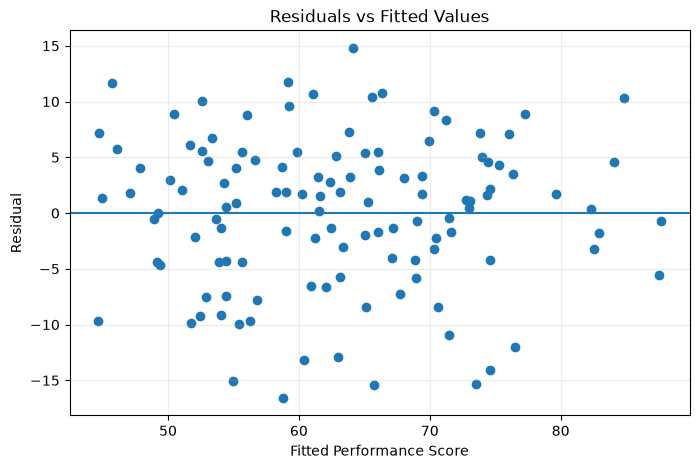

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0)
plt.xlabel("Fitted Performance Score")
plt.ylabel("Residual")
plt.title("Residuals vs Fitted Values")
plt.grid(alpha=0.25)
plt.show()


Look for residuals fluctuating around zero without a strong systematic pattern.

Potential warning signs include:

- curvature
- changing spread
- clusters
- unusual observations


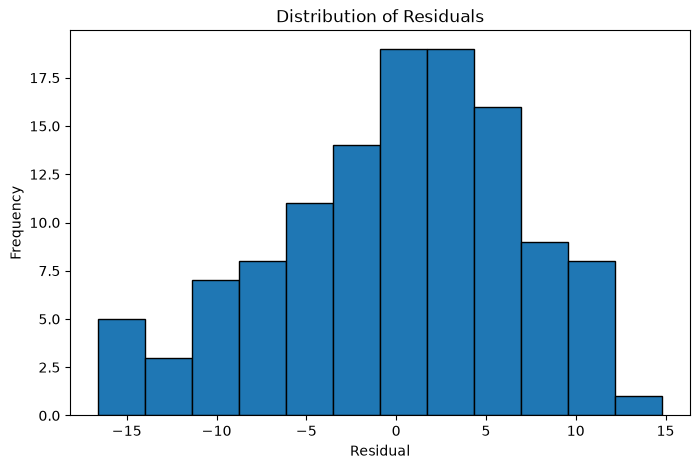

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(model.resid, bins=12, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()


The histogram gives a basic view of the residual distribution.

For classical small-sample inference, approximate normality of the errors is relevant, but diagnostics should not be treated as mechanical pass/fail rules.


## 16. Multicollinearity

A new issue becomes important when a model contains multiple predictors.

**Multicollinearity** occurs when predictors are strongly linearly related to one another.

When predictors contain overlapping information, it can become difficult to estimate their separate coefficients precisely.

Possible consequences include:

- larger standard errors
- unstable coefficient estimates
- coefficients that change substantially when predictors are added or removed
- difficulty interpreting individual coefficients


### Predictor Correlations

A useful first look is the correlation matrix among predictors.


In [17]:
predictor_names = [
    "training_hours",
    "experience_years",
    "project_load",
]

df[predictor_names].corr()


,training_hours,experience_years,project_load
training_hours,1.000000,0.400509,-0.146150
experience_years,0.400509,1.000000,-0.017478
project_load,-0.146150,-0.017478,1.000000


Pairwise correlations are useful, but they do not capture every form of multicollinearity.

A commonly used additional diagnostic is the **Variance Inflation Factor (VIF)**.


## 17. Variance Inflation Factor (VIF)

For predictor $X_j$,

$$
VIF_j
=
\frac{1}{1-R_j^2}
$$

where $R_j^2$ comes from regressing $X_j$ on the other predictors.

A larger VIF indicates that more of the predictor's variation can be linearly accounted for by the other predictors.

VIF is a diagnostic, not an automatic rule for deleting variables.


In [18]:
X_vif = df[predictor_names]

vif_table = pd.DataFrame({
    "predictor": predictor_names,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ],
})

vif_table


,predictor,VIF
0,training_hours,4.403771
1,experience_years,5.004161
2,project_load,2.814081


There is no single VIF cutoff that is appropriate in every analysis.

Interpret VIF together with:

- the research question
- predictor definitions
- study design
- coefficient uncertainty
- model purpose


## 18. Prediction with Multiple Predictors

Prediction now requires a value for **every predictor in the fitted model**.

Suppose we want a fitted performance score for an employee with:

- 8 training hours
- 6 years of experience
- 3 active projects


In [19]:
new_employee = pd.DataFrame({
    "const": [1.0],
    "training_hours": [8.0],
    "experience_years": [6.0],
    "project_load": [3],
})

prediction = model.get_prediction(new_employee).summary_frame(alpha=0.05)
prediction


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,69.374037,1.100556,67.194248,71.553826,55.595012,83.153062


As in Chapter 18:

- the mean-response confidence interval describes uncertainty about the conditional mean
- the prediction interval describes uncertainty for a new individual observation

The prediction interval is wider because individual outcomes vary around the regression surface.


## 19. Assumptions and Model Conditions

For the usual multiple linear regression inference, important considerations include:

1. **Linearity** — the conditional mean is appropriately represented by the chosen linear model.
2. **Independence** — observations or errors are appropriately independent for the study design.
3. **Constant variance** — residual variability is reasonably stable.
4. **Approximately normal errors for classical small-sample inference**.
5. **No observations that dominate the fitted result excessively**.
6. **Predictors do not create severe multicollinearity that prevents useful coefficient estimation**.

These conditions concern the regression model and data-generating process.

They should not be reduced to a checklist of automatic statistical tests.


## 20. Multiple Regression Does Not Automatically Establish Causation

Including additional predictors can help describe conditional associations.

It does **not** automatically eliminate:

- confounding
- omitted-variable bias
- reverse causality
- selection bias
- measurement error
- model misspecification

A coefficient should therefore be described as an adjusted association unless the study design and assumptions support a causal interpretation.


## 21. Simple vs Multiple Linear Regression

| Feature | Simple Regression | Multiple Regression |
|---|---|---|
| Number of predictors | 1 | 2 or more |
| Basic model | $Y=\beta_0+\beta_1X+\varepsilon$ | $Y=\beta_0+\beta_1X_1+\cdots+\beta_pX_p+\varepsilon$ |
| Coefficient interpretation | Change associated with $X$ | Change associated with $X_j$, holding other included predictors constant |
| Multicollinearity | Not applicable with one predictor | Important consideration |
| $R^2$ | Used | Used |
| Adjusted $R^2$ | Less central | Particularly useful for model comparison |

The core least-squares logic is the same.


## 22. A Practical Multiple Regression Workflow

$$
\text{Define Outcome and Predictors}
\rightarrow
\text{Inspect Data}
\rightarrow
\text{Fit Model}
\rightarrow
\text{Interpret Conditional Coefficients}
\rightarrow
\text{Evaluate Uncertainty}
\rightarrow
\text{Check Residuals}
\rightarrow
\text{Examine Multicollinearity}
\rightarrow
\text{Predict Carefully}
\rightarrow
\text{Avoid Unsupported Causal Claims}
$$


## 23. Exercises

### Exercise 1
Write the fitted regression equation using the estimated coefficients.

### Exercise 2
Interpret the coefficient for `training_hours` while holding the other predictors constant.

### Exercise 3
Interpret the coefficient for `project_load`.

### Exercise 4
Compare the training-hours coefficient from the simple regression model with the coefficient from the multiple regression model.

Why might they differ?

### Exercise 5
Compare $R^2$ and adjusted $R^2$.

Explain why adjusted $R^2$ is useful when multiple predictors are included.

### Exercise 6
Use the coefficient table to identify the estimate, standard error, t statistic, p-value, and confidence interval for each predictor.

### Exercise 7
Explain the null hypothesis of the overall F-test.

### Exercise 8
Inspect the residual plot and describe any visible patterns.

### Exercise 9
Calculate VIF values and explain what they tell you about the predictors.

### Exercise 10
Predict the performance score for an employee with:

- 5 training hours
- 10 years of experience
- 5 active projects

Report both the mean-response confidence interval and the individual prediction interval.


## 24. Summary

Multiple linear regression extends simple linear regression from one predictor to several predictors:

$$
Y
=
\beta_0
+
\beta_1X_1
+
\cdots
+
\beta_pX_p
+
\varepsilon
$$

The central new interpretation is:

> Each coefficient describes the estimated association between its predictor and the outcome **while holding the other included predictors constant**.

Key ideas:

- least squares still minimizes squared residuals
- coefficients are conditional on the other included predictors
- $R^2$ measures in-sample variation accounted for by the fitted model
- adjusted $R^2$ accounts for the number of predictors
- t-tests evaluate individual coefficients
- the F-test evaluates the predictor set jointly
- residual diagnostics remain essential
- multicollinearity can make separate coefficients difficult to estimate precisely
- VIF is one diagnostic for multicollinearity
- adding predictors does not automatically create a causal model

### Next Chapter

**Chapter 20 — Logistic Regression**

So far, regression has used a quantitative outcome.

Next, we will model a **binary outcome**, such as:

$$
Y \in \{0,1\}
$$

This introduces probabilities, odds, and the logistic function.
